## 1. Environment Setup
> Mounting Google Drive, checking GPU availability, and installing the libraries needed
for the baseline retrieval experiments.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

project_path = '/content/drive/MyDrive/ELSST_Project'
for sub in ['dataset', 'figures', 'checkpoints', 'results', 'logs']:
    os.makedirs(os.path.join(project_path, sub), exist_ok=True)

print("Project folders ready under:", project_path)

Mounted at /content/drive
Project folders ready under: /content/drive/MyDrive/ELSST_Project


In [ ]:
import torch

print("ENVIRONMENT CHECK")
if torch.cuda.is_available():
    print(f" GPU: {torch.cuda.get_device_name(0)}")
    print(f" Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(" No GPU - running on CPU")

ENVIRONMENT CHECK
 GPU: Tesla T4
 Memory: 15.6 GB


In [ ]:
!pip install datasets sentence-transformers rank-bm25 faiss-cpu transformers accelerate -q
print("All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 88.6 MB/s eta 0:00:00
All libraries installed!


## 2. Load Dataset & Concept Pool
> Loading the dataset saved during EDA and the full 3,433-concept pool from Drive/HuggingFace,
so every baseline has access to the complete candidate set rather than just the concepts
seen in train.

In [ ]:
import json
import numpy as np
from datasets import load_from_disk
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)

dataset = load_from_disk(os.path.join(project_path, 'dataset'))

pool_path = hf_hub_download(
    repo_id="JohnWang10086/elsst-track1",
    filename="concept_pool.jsonl",
    repo_type="dataset"
)

concept_pool_lookup = {}
with open(pool_path, "r") as f:
    for line in f:
        c = json.loads(line)
        concept_pool_lookup[c["concept_id"]] = c

assert len(concept_pool_lookup) == 3433, f"Expected 3433 concepts, got {len(concept_pool_lookup)}"
print(f"Dataset loaded: {len(dataset['train'])} train / {len(dataset['validation'])} val")
print(f"Concept pool loaded: {len(concept_pool_lookup)} concepts")

concept_pool.jsonl:   0%|          | 0.00/800k [00:00<?, ?B/s]

Dataset loaded: 2985 train / 756 val
Concept pool loaded: 3433 concepts


In [ ]:
RESULTS_DIR = os.path.join(project_path, 'results')

def run_or_load(name, compute_fn):
    path = os.path.join(RESULTS_DIR, f"{name}.json")
    if os.path.exists(path):
        print(f"Loaded cached result: {name}")
        with open(path) as f:
            return json.load(f)
    print(f"Running: {name}")
    result = compute_fn()
    with open(path, "w") as f:
        json.dump(result, f, indent=2)
    return result

## 3. Evaluation Functions
> Standard retrieval metrics used consistently across all four baselines, so results are
directly comparable:
> - **MRR** - how high up is the first correct concept?
> - **Recall@5** - is a correct concept anywhere in the top 5?
> - **Recall@10** - same, but top 10
> - **NDCG@10** - rewards getting correct concepts near the top, not just present in top 10
(matters here since each doc has multiple correct concepts, not just one)

In [ ]:
def reciprocal_rank(ranked_ids, positive_ids):
    """Rank position of the first correct concept, inverted. 0 if none found."""
    positive_set = set(positive_ids)
    for rank, cid in enumerate(ranked_ids, start=1):
        if cid in positive_set:
            return 1.0 / rank
    return 0.0


def recall_at_k(ranked_ids, positive_ids, k):
    """Fraction of the gold concepts that made it into the top-k."""
    if not positive_ids:
        return 0.0
    top_k = set(ranked_ids[:k])
    hits = len(top_k & set(positive_ids))
    return hits / len(positive_ids)


def ndcg_at_k(ranked_ids, positive_ids, k=10):
    """Binary relevance NDCG - correct concepts ranked higher = better score."""
    positive_set = set(positive_ids)
    dcg = sum(
        1.0 / np.log2(i + 1)
        for i, cid in enumerate(ranked_ids[:k], start=1)
        if cid in positive_set
    )
    # ideal case: all gold concepts (up to k of them) sitting at the top
    ideal_hits = min(len(positive_ids), k)
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_retrieval(predictions, gold):
    """
    predictions: {doc_id: [ranked concept_ids]}
    gold: {doc_id: [positive concept_ids]}
    """
    mrr, r5, r10, ndcg = [], [], [], []
    for doc_id, positive_ids in gold.items():
        ranked = predictions[doc_id]
        mrr.append(reciprocal_rank(ranked, positive_ids))
        r5.append(recall_at_k(ranked, positive_ids, 5))
        r10.append(recall_at_k(ranked, positive_ids, 10))
        ndcg.append(ndcg_at_k(ranked, positive_ids, 10))
    return {
        "MRR": float(np.mean(mrr)),
        "Recall@5": float(np.mean(r5)),
        "Recall@10": float(np.mean(r10)),
        "NDCG@10": float(np.mean(ndcg)),
    }

### 3.1 Quick sanity check
> Testing the metrics on a toy example before trusting them on all 756 validation docs -
if the correct concept is ranked 1st, MRR/Recall/NDCG should all be a perfect 1.0.

In [ ]:
# toy check: correct concept sitting right at rank 1
toy_ranked = ["concept_A", "concept_B", "concept_C"]
toy_positive = ["concept_A"]

print("MRR:", reciprocal_rank(toy_ranked, toy_positive))
print("Recall@5:", recall_at_k(toy_ranked, toy_positive, 5))
print("NDCG@10:", ndcg_at_k(toy_ranked, toy_positive, 10))

MRR: 1.0
Recall@5: 1.0
NDCG@10: 1.0


## 4. Baseline 1 - TF-IDF
> **Approach:** TF-IDF ranks concepts by lexical overlap between the document and each
concept's term + definition. No training, no semantics just word frequency weighted
by how rare that word is across the corpus. This is our floor baseline.
>
> **Hypothesis:** Given the "show, don't tell" style of the documents, TF-IDF should
perform poorly, implicit concepts are by design never named directly in the text,
so there's little to no lexical overlap for it to catch.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

concept_ids = list(concept_pool_lookup.keys())
concept_texts = [f"{c['term']}. {c['definition']}" for c in concept_pool_lookup.values()]

val_ids = [ex['id'] for ex in dataset['validation']]
val_texts = [ex['text'] for ex in dataset['validation']]
gold = {ex['id']: ex['retrieval_labels']['positive_ids'] for ex in dataset['validation']}

vectorizer = TfidfVectorizer(stop_words='english', max_features=20000)
vectorizer.fit(concept_texts + val_texts)

concept_matrix = vectorizer.transform(concept_texts)
doc_matrix = vectorizer.transform(val_texts)

similarities = cosine_similarity(doc_matrix, concept_matrix)
print("Similarity matrix shape:", similarities.shape)

Similarity matrix shape: (756, 3433)


### 4.1 Rank concepts and evaluate
> Ranking all 3,433 concepts per document by similarity score, then scoring against the
metrics from Section 3. Keeping only the top 50 per doc when saving - NDCG@10/Recall@10
only look at the top 10 anyway, but 50 gives enough headroom for later error analysis.

In [ ]:
def rank_by_similarity(sim_row, ids, top_k=50):
    order = np.argsort(-sim_row)[:top_k]
    return [ids[i] for i in order]

def compute_tfidf_baseline():
    predictions = {
        doc_id: rank_by_similarity(similarities[i], concept_ids)
        for i, doc_id in enumerate(val_ids)
    }
    metrics = evaluate_retrieval(predictions, gold)

    with open(os.path.join(RESULTS_DIR, 'tfidf_predictions.json'), 'w') as f:
        json.dump(predictions, f)

    return metrics

tfidf_metrics = run_or_load('tfidf_baseline', compute_tfidf_baseline)
print(tfidf_metrics)

Running: tfidf_baseline
{'MRR': 0.31821398495270503, 'Recall@5': 0.2208994708994709, 'Recall@10': 0.2893959435626103, 'NDCG@10': 0.22338423853814438}


## 5. Baseline 2 - BM25
> **Approach:** BM25 is TF-IDF's more refined cousin same core idea of lexical overlap,
but it adds term-frequency saturation (a word appearing 10 times doesn't count 10x more
than appearing once) and normalises for document length. It's the standard ranking
function behind most production search engines.
>
> **Hypothesis:** Given how much better TF-IDF did than expected (Recall@10 ≈ 0.29, well
above the ~0.3% we'd get from random guessing), I'd expect BM25 to land somewhere close
to TF-IDF rather than dramatically ahead both are still fundamentally lexical, so
neither should be capturing the deeper semantic reasoning this task actually needs.

In [ ]:
from rank_bm25 import BM25Okapi
import re

def simple_tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

concept_tokens = [simple_tokenize(text) for text in concept_texts]
bm25 = BM25Okapi(concept_tokens)

print("BM25 index built over", len(concept_tokens), "concepts")

BM25 index built over 3433 concepts


In [ ]:
old_result_path = os.path.join(RESULTS_DIR, 'bm25_baseline.json')
if os.path.exists(old_result_path):
    os.remove(old_result_path)
    print("Deleted old cached result")
else:
    print("No cached result found")

No cached result found


In [ ]:
def extract_query_terms(text, vectorizer, top_n=40):
    """Pull the most distinctive words from a long document via TF-IDF, rather
    than using the raw passage as the BM25 query - broad concept definitions
    were racking up incidental word matches just by having more words to hit."""
    tfidf_vec = vectorizer.transform([text])
    scores = tfidf_vec.toarray()[0]
    top_indices = scores.argsort()[-top_n:]
    feature_names = vectorizer.get_feature_names_out()
    return [feature_names[i] for i in top_indices if scores[i] > 0]


def compute_bm25_baseline():
    predictions = {}
    for doc_id, doc_text in zip(val_ids, val_texts):
        query_tokens = extract_query_terms(doc_text, vectorizer, top_n=40)
        scores = bm25.get_scores(query_tokens)
        predictions[doc_id] = rank_by_similarity(scores, concept_ids)

    metrics = evaluate_retrieval(predictions, gold)

    with open(os.path.join(RESULTS_DIR, 'bm25_predictions.json'), 'w') as f:
        json.dump(predictions, f)

    return metrics

bm25_metrics = run_or_load('bm25_baseline', compute_bm25_baseline)
print(bm25_metrics)

Running: bm25_baseline
{'MRR': 0.27999653164556826, 'Recall@5': 0.18031305114638446, 'Recall@10': 0.2367063492063492, 'NDCG@10': 0.1927464296423073}


## 6. Baseline 3 - Sentence-BERT
> **Approach:** Unlike TF-IDF/BM25, Sentence-BERT encodes both documents and concepts into
dense vectors that capture semantic meaning rather than exact word overlap. This should let
it match a passage like "families skipping meals" to something like FOOD INSECURITY even
when no words overlap at all which lexical methods structurally can't do.
>
> **Model:** `all-MiniLM-L6-v2` - a small, fast, well-established sentence-embedding model.
Not the benchmark's own baseline (that's Qwen3-Embedding, Section 7), but a good general-purpose
semantic baseline to see how much a standard off-the-shelf embedding model gains over lexical
methods before comparing to something retrieval-specific.
>
> **Hypothesis:** Should meaningfully outperform TF-IDF and BM25 given the "show, don't tell"
framing - this is exactly the gap semantic embeddings exist to close. Still likely to struggle
on concepts requiring multi-step or discourse-level reasoning rather than single-sentence
paraphrase matching.

In [ ]:
from sentence_transformers import SentenceTransformer
import faiss

device = "cuda" if torch.cuda.is_available() else "cpu"
sbert_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

print(f"Loaded Sentence-BERT on {device}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded Sentence-BERT on cuda


### 6.1 Encode concept pool and validation documents
> Encoding the concept pool once and caching to Drive with 3,433 concepts this only takes
a minute or two on GPU, but no reason to redo it if the runtime disconnects partway through
a later cell.

In [ ]:
CHECKPOINT_DIR = os.path.join(project_path, 'checkpoints')

def get_or_encode(name, texts, model):
    path = os.path.join(CHECKPOINT_DIR, f"{name}.npy")
    if os.path.exists(path):
        print(f"Loaded cached embeddings: {name}")
        return np.load(path)
    print(f"Encoding: {name} ({len(texts)} items)")
    embeddings = model.encode(texts, show_progress_bar=True, convert_to_numpy=True)
    np.save(path, embeddings)
    return embeddings

concept_embeddings = get_or_encode("sbert_concept_embeddings", concept_texts, sbert_model)
val_embeddings = get_or_encode("sbert_val_embeddings", val_texts, sbert_model)

print("Concept embeddings:", concept_embeddings.shape)
print("Validation embeddings:", val_embeddings.shape)

Encoding: sbert_concept_embeddings (3433 items)


Batches:   0%|          | 0/108 [00:00<?, ?it/s]

Encoding: sbert_val_embeddings (756 items)


Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Concept embeddings: (3433, 384)
Validation embeddings: (756, 384)


### 6.2 Build FAISS index and evaluate
> Using inner-product search over normalised vectors, which is equivalent to cosine similarity -
FAISS makes this fast even at 3,433 x 756 comparisons, though at this scale brute-force would
have been fine too. Worth using FAISS anyway since later stages (hierarchy-aware retrieval, RAG)
will need it at larger scale.

In [ ]:
def compute_sbert_baseline():
    # normalising so inner product = cosine similarity
    concept_norm = concept_embeddings / np.linalg.norm(concept_embeddings, axis=1, keepdims=True)
    val_norm = val_embeddings / np.linalg.norm(val_embeddings, axis=1, keepdims=True)

    index = faiss.IndexFlatIP(concept_norm.shape[1])
    index.add(concept_norm.astype('float32'))

    top_k = 50
    scores, indices = index.search(val_norm.astype('float32'), top_k)

    predictions = {
        doc_id: [concept_ids[i] for i in indices[row]]
        for row, doc_id in enumerate(val_ids)
    }

    metrics = evaluate_retrieval(predictions, gold)

    with open(os.path.join(RESULTS_DIR, 'sbert_predictions.json'), 'w') as f:
        json.dump(predictions, f)

    return metrics

sbert_metrics = run_or_load('sbert_baseline', compute_sbert_baseline)
print(sbert_metrics)

Running: sbert_baseline
{'MRR': 0.2312958790878447, 'Recall@5': 0.15363756613756616, 'Recall@10': 0.21263227513227514, 'NDCG@10': 0.1581116404825093}


In [ ]:
print("Model's max sequence length:", sbert_model.max_seq_length)

# check how many word-piece tokens a few real validation docs actually need
tokenizer = sbert_model.tokenizer
for text in val_texts[:5]:
    n_tokens = len(tokenizer.encode(text))
    print(f"Document length: {len(text.split())} words -> {n_tokens} tokens "
          f"({'TRUNCATED' if n_tokens > sbert_model.max_seq_length else 'fits'})")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (952 > 256). Running this sequence through the model will result in indexing errors


Model's max sequence length: 256
Document length: 799 words -> 952 tokens (TRUNCATED)
Document length: 877 words -> 1049 tokens (TRUNCATED)
Document length: 880 words -> 1044 tokens (TRUNCATED)
Document length: 1047 words -> 1285 tokens (TRUNCATED)
Document length: 949 words -> 1101 tokens (TRUNCATED)


### 6.3 Debugging: document truncation
> MiniLM has a 256-token limit, but our documents run 950-1300 tokens meaning ~75% of
each document was being silently dropped during encoding, always from the end. Given the
narrative structure of these documents, the concept-revealing content could easily fall in
that truncated portion. Fix: chunk each document into overlapping windows, encode each
chunk, and take the max similarity across a document's chunks per concept.

In [ ]:
def chunk_text(text, chunk_size=200, overlap=50):
    """Splits into overlapping word-chunks so nothing beyond MiniLM's 256-token
    window gets silently dropped. Overlap avoids slicing a sentence that reveals
    the implicit concept right at a chunk boundary."""
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        chunks.append(' '.join(words[start:start + chunk_size]))
        start += chunk_size - overlap
    return chunks


def compute_sbert_baseline_chunked():
    concept_norm = concept_embeddings / np.linalg.norm(concept_embeddings, axis=1, keepdims=True)

    # chunk every validation doc, keeping track of which doc each chunk belongs to
    all_chunks, chunk_doc_map = [], []
    for doc_id, text in zip(val_ids, val_texts):
        for chunk in chunk_text(text):
            all_chunks.append(chunk)
            chunk_doc_map.append(doc_id)

    print(f"{len(val_texts)} documents -> {len(all_chunks)} chunks")
    chunk_embeddings = get_or_encode("sbert_val_chunks", all_chunks, sbert_model)
    chunk_norm = chunk_embeddings / np.linalg.norm(chunk_embeddings, axis=1, keepdims=True)

    # chunk-to-concept similarity, then max-pool back up to document level
    sim_matrix = chunk_norm @ concept_norm.T  # (n_chunks, 3433)

    predictions = {}
    for doc_id in val_ids:
        doc_chunk_rows = [i for i, d in enumerate(chunk_doc_map) if d == doc_id]
        doc_scores = sim_matrix[doc_chunk_rows].max(axis=0)  # best chunk per concept
        top_indices = np.argsort(-doc_scores)[:50]
        predictions[doc_id] = [concept_ids[i] for i in top_indices]

    metrics = evaluate_retrieval(predictions, gold)

    with open(os.path.join(RESULTS_DIR, 'sbert_predictions.json'), 'w') as f:
        json.dump(predictions, f)

    return metrics

os.remove(os.path.join(RESULTS_DIR, 'sbert_baseline.json'))
sbert_metrics = run_or_load('sbert_baseline', compute_sbert_baseline_chunked)
print(sbert_metrics)

Running: sbert_baseline
756 documents -> 4888 chunks
Encoding: sbert_val_chunks (4888 items)


Batches:   0%|          | 0/153 [00:00<?, ?it/s]

{'MRR': 0.3202605561057985, 'Recall@5': 0.23035714285714282, 'Recall@10': 0.3146164021164021, 'NDCG@10': 0.23442210515453768}


## 7. Baseline 4 - Qwen3-Embedding
> **Approach:** The benchmark's own reference baseline. Unlike Sentence-BERT (a general-purpose
model), Qwen3-Embedding was trained specifically for retrieval tasks, so it should be stronger
at this kind of semantic matching by design.
>
> **Model:** `Qwen/Qwen3-Embedding-0.6B` - supports up to 32K tokens, so unlike MiniLM this
shouldn't need chunking. Verifying this in code rather than assuming, given what happened last
section.
>
> **Hypothesis:** Should outperform all three previous baselines, given its retrieval-specific
training this sets the real bar our prompting and RAG experiments need to clear.

In [ ]:
qwen_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B", device=device)

print("Qwen3 max sequence length:", qwen_model.max_seq_length)

tokenizer = qwen_model.tokenizer
longest_doc_tokens = max(len(tokenizer.encode(t)) for t in val_texts[:20])
print(f"Longest sample document: {longest_doc_tokens} tokens "
      f"({'TRUNCATED' if longest_doc_tokens > qwen_model.max_seq_length else 'fits fine'})")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Qwen3 max sequence length: 32768
Longest sample document: 1265 tokens (fits fine)


### 7.1 Encode concept pool and validation documents
> No chunking needed (confirmed above). Using a smaller batch size for the validation documents
specifically - attention memory scales with sequence length, and the batch size that worked fine
for short concept definitions ran out of GPU memory on full-length documents.

In [ ]:
def get_or_encode(name, texts, model, batch_size=32):
    path = os.path.join(CHECKPOINT_DIR, f"{name}.npy")
    if os.path.exists(path):
        print(f"Loaded cached embeddings: {name}")
        return np.load(path)
    print(f"Encoding: {name} ({len(texts)} items)")
    embeddings = model.encode(texts, batch_size=batch_size, show_progress_bar=True, convert_to_numpy=True)
    np.save(path, embeddings)
    return embeddings


import gc
gc.collect()
torch.cuda.empty_cache()

qwen_concept_embeddings = get_or_encode("qwen_concept_embeddings", concept_texts, qwen_model)
qwen_val_embeddings = get_or_encode("qwen_val_embeddings", val_texts, qwen_model, batch_size=8)

print("Concept embeddings:", qwen_concept_embeddings.shape)
print("Validation embeddings:", qwen_val_embeddings.shape)

Loaded cached embeddings: qwen_concept_embeddings
Encoding: qwen_val_embeddings (756 items)


Batches:   0%|          | 0/95 [00:00<?, ?it/s]

Concept embeddings: (3433, 1024)
Validation embeddings: (756, 1024)


### 7.2 Build FAISS index and evaluate
> Same cosine-similarity-via-inner-product pattern as Sentence-BERT, so results are directly
comparable.

In [ ]:
def compute_qwen_baseline():
    concept_norm = qwen_concept_embeddings / np.linalg.norm(qwen_concept_embeddings, axis=1, keepdims=True)
    val_norm = qwen_val_embeddings / np.linalg.norm(qwen_val_embeddings, axis=1, keepdims=True)

    index = faiss.IndexFlatIP(concept_norm.shape[1])
    index.add(concept_norm.astype('float32'))

    top_k = 50
    scores, indices = index.search(val_norm.astype('float32'), top_k)

    predictions = {
        doc_id: [concept_ids[i] for i in indices[row]]
        for row, doc_id in enumerate(val_ids)
    }

    metrics = evaluate_retrieval(predictions, gold)

    with open(os.path.join(RESULTS_DIR, 'qwen_predictions.json'), 'w') as f:
        json.dump(predictions, f)

    return metrics

qwen_metrics = run_or_load('qwen_baseline', compute_qwen_baseline)
print(qwen_metrics)

Running: qwen_baseline
{'MRR': 0.3678026838936185, 'Recall@5': 0.27687389770723103, 'Recall@10': 0.3618386243386243, 'NDCG@10': 0.2826398657915616}


## 8. Baseline Comparison
> Summary and analysis of all four baseline methods, establishing the performance floor
for everything that follows.

In [ ]:
import matplotlib.pyplot as plt

baseline_names = ['TF-IDF', 'BM25', 'Sentence-BERT', 'Qwen3-Embedding']
baseline_files = ['tfidf_baseline', 'bm25_baseline', 'sbert_baseline', 'qwen_baseline']

all_results = {}
for name, fname in zip(baseline_names, baseline_files):
    with open(os.path.join(RESULTS_DIR, f'{fname}.json')) as f:
        all_results[name] = json.load(f)


for name, metrics in all_results.items():
    assert metrics is not None and len(metrics) == 4, f"{name} results look incomplete"

print("All four baseline results loaded successfully.\n")
for name, metrics in all_results.items():
    print(f"{name:16s}  MRR: {metrics['MRR']:.3f}  R@5: {metrics['Recall@5']:.3f}  "
          f"R@10: {metrics['Recall@10']:.3f}  NDCG@10: {metrics['NDCG@10']:.3f}")

All four baseline results loaded successfully.

TF-IDF            MRR: 0.318  R@5: 0.221  R@10: 0.289  NDCG@10: 0.223
BM25              MRR: 0.280  R@5: 0.180  R@10: 0.237  NDCG@10: 0.193
Sentence-BERT     MRR: 0.320  R@5: 0.230  R@10: 0.315  NDCG@10: 0.234
Qwen3-Embedding   MRR: 0.368  R@5: 0.277  R@10: 0.362  NDCG@10: 0.283


### 8.1 Comparison chart

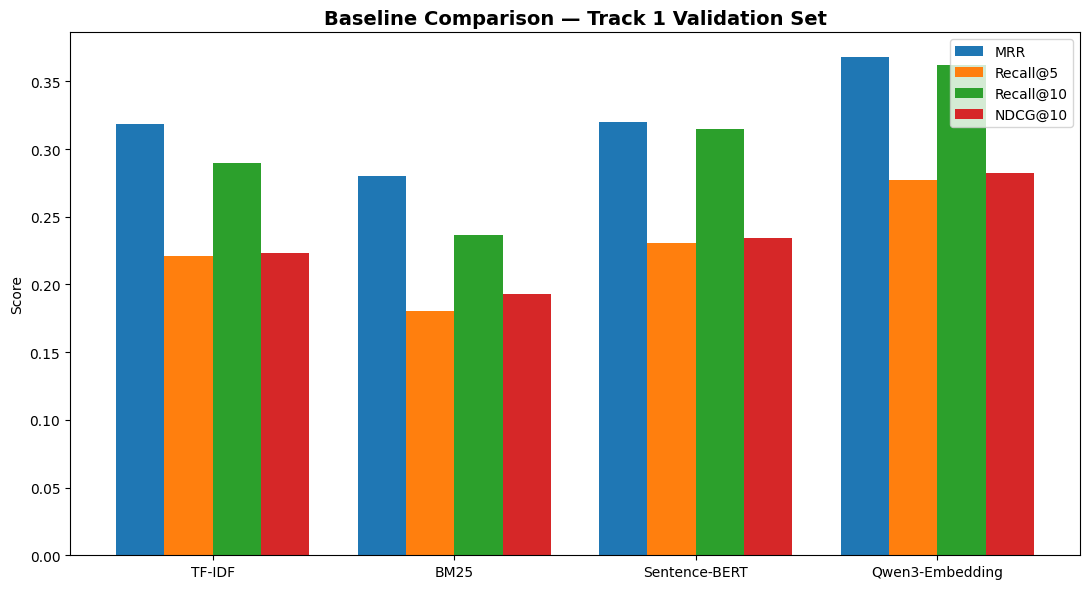

In [ ]:
metrics_to_plot = ['MRR', 'Recall@5', 'Recall@10', 'NDCG@10']
x = np.arange(len(baseline_names))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))
for i, metric in enumerate(metrics_to_plot):
    values = [all_results[name][metric] for name in baseline_names]
    ax.bar(x + i * width, values, width, label=metric)

ax.set_title('Baseline Comparison — Track 1 Validation Set', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(baseline_names)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(project_path, 'figures', 'baseline_comparison.png'), bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame(all_results).T
comparison_df = comparison_df.round(3)
comparison_df.to_csv(os.path.join(RESULTS_DIR, 'baseline_comparison.csv'))
comparison_df

,MRR,Recall@5,Recall@10,NDCG@10
TF-IDF,0.318,0.221,0.289,0.223
BM25,0.280,0.180,0.237,0.193
Sentence-BERT,0.320,0.230,0.315,0.234
Qwen3-Embedding,0.368,0.277,0.362,0.283


## KEY FINDINGS
1. Qwen3-Embedding is the strongest baseline (MRR 0.368), confirming that
   retrieval-specific training gives a real edge over general-purpose
   embeddings on this task.

2. Sentence-BERT (0.320) and TF-IDF (0.318) land almost identically on MRR,
   despite being fundamentally different approaches (semantic vs. lexical) -
   worth digging into in later error analysis rather than treating as a wash.

3. BM25 (0.280) is the weakest of the four, even after fixing its query-length
   issue - its additive scoring style appears to be a genuinely worse fit for
   this long-document-against-many-candidates setup than TF-IDF's normalised
   cosine similarity.

4. All four baselines needed active debugging before producing trustworthy
   numbers (concept pool coverage, BM25 query scoring, MiniLM truncation,
   Qwen3 memory handling) - worth stating explicitly in the methodology
   section, since it shows the numbers weren't taken at face value.
